In [1]:
import numpy as np
import inspect
import importlib
import Utils
importlib.reload(Utils)
from rasterstats import zonal_stats
import Constants
importlib.reload(Constants)
import ConstantObjects
import matplotlib.pyplot as plt

import rasterio
from rasterio.warp import reproject, Resampling





[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

In [3]:
# Re-run the previous code after reset

#dates = Utils.generate_date_range("2025-01-02", "2025-06-10",  "%Y-%m-%d", 5)
# Veracruz, 2025-02-06,11 was remarkably clear day
# 1-12 had no clouds directly over ranch.
# 2-11 had clouds over ranch.
#Port isabel date 2025-01-05 is cloud free:
dates = Utils.generate_date_range("2022-01-08", "2022-01-08",  "%Y-%m-%d", 5)

print("dates = ",dates)

#NDMI = Normalized Difference Moisture Index
# Output lists
ndmi_values = []
valid_dates = []




# Prepare folder
#os.makedirs("s2_point_series", exist_ok=True)
output_tif_cumulative = "ndmi_cumulative.tif"
output_tif =""
rgb_tif =""
# Sample NDMI at the given point
for date in dates:
    print("processing date ",date)
    b02_path = Utils.download_band_dynamic(date, "B02",Constants.lat0,Constants.lon0)
    b03_path = Utils.download_band_dynamic(date, "B03",Constants.lat0,Constants.lon0)

    b08_path = Utils.download_band_dynamic(date, "B08",Constants.lat0,Constants.lon0)
    b11_path = Utils.download_band_dynamic(date, "B11",Constants.lat0,Constants.lon0)
    b04_path = Utils.download_band_dynamic(date, "B04",Constants.lat0,Constants.lon0)

    print("b08_path ", b08_path)
    print("b11_path ",  b11_path)
    print("b04_path ",  b04_path)

    print(f"[Line {inspect.currentframe().f_lineno}] ... About to try ")
    try:
        with rasterio.open(b08_path) as src_b08, rasterio.open(b11_path) as src_b11 , rasterio.open(b04_path) as src_b04 : # , rasterio.open(b02_path) as src_b02, rasterio.open(b03_path) as src_b03, rasterio.open(b04_path) as src_b04:
            print(f"[Line {inspect.currentframe().f_lineno}] ... ")

            
            output_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date,"ndmi","tif"   ) #"ndmi_fixed.tif"
            print ("check 3")

            Utils.write_ndmi_geotiff(b08_path, b11_path, output_tif)
            print("✅ NDMI GeoTIFF saved to:", output_tif)
            rgb_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date,"rgb.float32","tif"   ) #"ndmi_fixed.tif"

            Utils.write_truecolor_geotiff(b02_path, b03_path, b04_path, rgb_tif)

  
            print(f"[Line {inspect.currentframe().f_lineno}] ... ")

    

            print(f"[Line {inspect.currentframe().f_lineno}] ... ")
    

                
    except Exception as e:
        print(f"Skipping {date} due to error: {e}")
print("valid_dates ",valid_dates)
#print("ndmi_values ",ndmi_values)
print("done with cell ")




dates =  ['2022-01-08']
processing date  2022-01-08
[Line 124] ... found mgrs_tile =  14QQG
[Line 124] ... found mgrs_tile =  14QQG
[Line 124] ... found mgrs_tile =  14QQG
[Line 124] ... found mgrs_tile =  14QQG
[Line 124] ... found mgrs_tile =  14QQG
b08_path  s2_point_series/14QQG_2022-01-08_B08.jp2
b11_path  s2_point_series/14QQG_2022-01-08_B11.jp2
b04_path  s2_point_series/14QQG_2022-01-08_B04.jp2
[Line 39] ... About to try 
[Line 42] ... 
[Line 124] ... found mgrs_tile =  14QQG
band = > ndmi <
extension = > tif <
check 3
✅ NDMI GeoTIFF saved to: s2_derived_tifs/14QQG_2022-01-08_ndmi.tif
[Line 124] ... found mgrs_tile =  14QQG
band = > rgb.float32 <
extension = > tif <
Skipping 2022-01-08 due to error: module 'Utils' has no attribute 'write_truecolor_geotiff'
valid_dates  []
done with cell 


In [4]:
import leafmap
importlib.reload(ConstantObjects)
importlib.reload(Utils)

ndmi_cumulative_save_path = "ndmi_tifs/ndmi_terreno_casa.cumulative.tif"


[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

In [24]:
# Only run if you need to see the latest ndmi raster overlaid on the basemap

import leafmap
import importlib
#import ConstantObjects
importlib.reload(ConstantObjects)
m2 = leafmap.Map(center=(Constants.lat0,Constants.lon0), zoom=15)
gndvi_tif = Utils.make_path_name("s2_derived_tifs", Utils.latlon_to_s2_tile(Constants.lat0, Constants.lon0),date,"gndvi","tif"   ) #"ndmi_fixed.tif"

m2.add_basemap("Esri.WorldImagery")  # Google satellite imagery
#m2.add_raster(output_tif, layer_name="NDMI", colormap="BrBG", nodata=np.nan, opacity = .9)
#m2.add_raster(gndvi_tif, layer_name="NDMI", colormap="BrBG", nodata=np.nan, opacity = .6)

#
#print ("adding raster rgb_tif = ",rgb_tif)
##m2.add_raster(rgb_tif, layer_name="rgb", colormap="BrBG", nodata=np.nan, opacity = .99)
print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")


print(f"[Cell Line {inspect.currentframe().f_lineno}] .. ")

#m2.add_gdf(ConstantObjects.gdf_box_terreno_casa, layer_name="Plot Boundary")

#m2.add_gdf(ConstantObjects.gdf_box_casa_y_vecino, layer_name="casa y vecino")
m2.add_gdf(ConstantObjects.gdf_box_milpa_vecino, layer_name="milpa vecino")

m2.add_gdf(ConstantObjects.gdf_box_plots_4_5, layer_name="Plots 4,5")
m2.add_gdf(ConstantObjects.gdf_box_plots_2_3_1A_1B , layer_name="Plots 2,3,1A,1B")
m2.add_gdf(ConstantObjects.gdf_plotMilpa1 , layer_name="Milpa1")
                           
#m2.add_gdf(ConstantObjects.gdf_plotMilpa1SinHormiguero , layer_name="Milpa1SinHormiguero")

#m2.add_gdf(ConstantObjects.gdf_plotMilpa2 , layer_name="Milpa1")

#m2.add_gdf(ConstantObjects.gdf_box_pueblo, layer_name="pueblo")
#m2.add_gdf(ConstantObjects.gdf_box_river, layer_name="river")
m2.center=(Constants.lat0,Constants.lon0)
m2.zoom = 18
print(f"[Line {inspect.currentframe().f_lineno}] ... b04_path = ",b04_path)


m2

[Line 13] n_cols in ConstantObjects: 21
[Line 15] n_cols: 21, n_rows: 18
[Line 26] n_cols in ConstantObjects: 21
[Line 28] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

Map(center=[19.7782, -96.86942], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

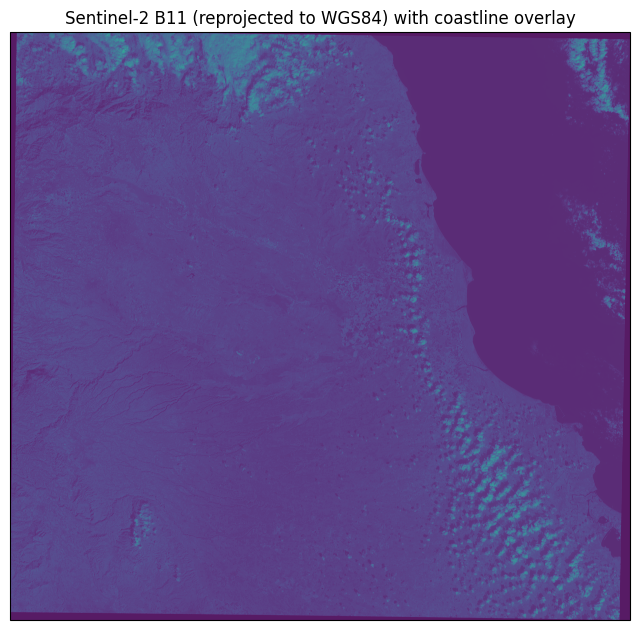

In [22]:



import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Input JP2 (UTM) and output (WGS84)
#infile = "14QQG_2025-03-03_B11.jp2"
infile = "s2_point_series/14QQG_2025-02-06_B08.jp2"

outfile = "14QQG_2025-03-03_B11_wgs84.tif"

# Reproject to WGS84
with rasterio.open(infile) as src:
    dst_crs = "EPSG:4326"
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({"crs": dst_crs, "transform": transform, "width": width, "height": height})

    with rasterio.open(outfile, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

# Read reprojected raster
with rasterio.open(outfile) as src:
    img = src.read(1)
    extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)

# Plot with Natural Earth coastline (auto-downloaded by Cartopy)
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
# High-res coastline (10m). If it’s too heavy, try '50m' or '110m'
#coast_10m = cfeature.NaturalEarthFeature("physical", "coastline", "10m")
#ax.add_feature(coast_10m, linewidth=1)
ax.imshow(img, extent=extent, origin="upper", transform=ccrs.PlateCarree(), alpha=.9)

ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.set_title("Sentinel-2 B11 (reprojected to WGS84) with coastline overlay")
plt.show()


Wrote: s2_truecolor_UTM.tif CRS: EPSG:32614
NDMI CRS: EPSG:4326 TrueColor CRS: EPSG:32614


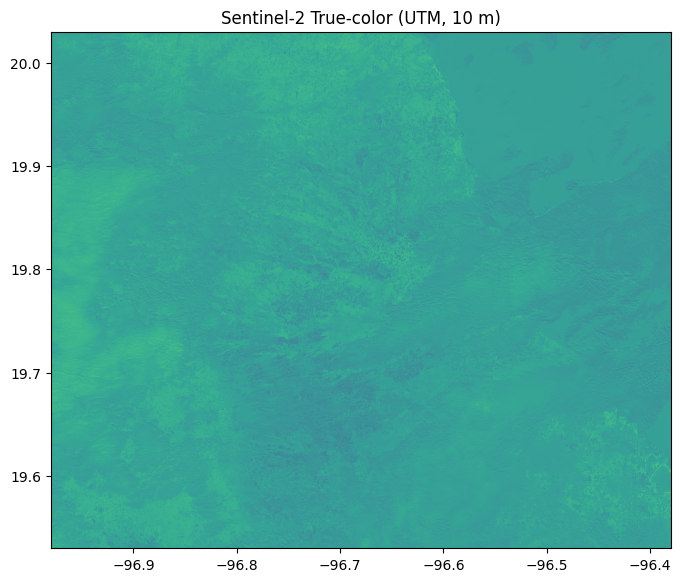

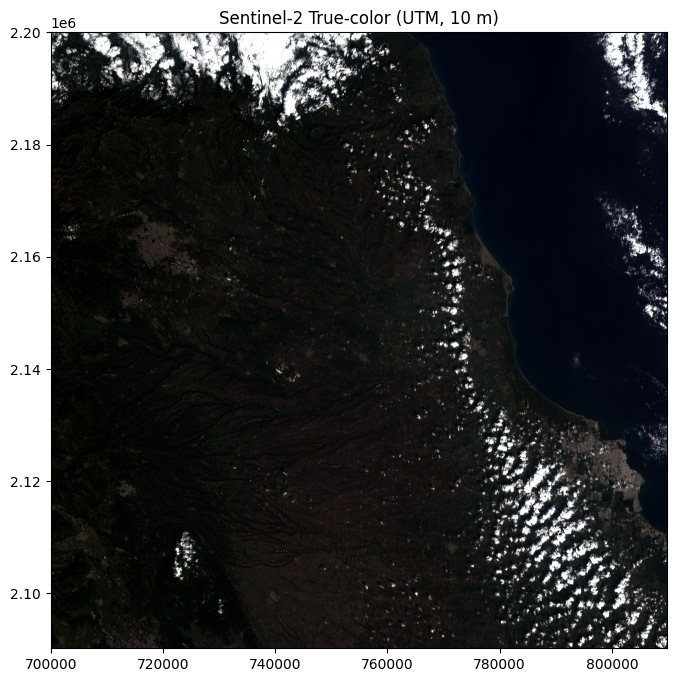

In [23]:
import numpy as np
import rasterio
from rasterio.plot import reshape_as_raster, reshape_as_image

# Paths for the SAME tile/date (e.g., 14QQG, YYYY-MM-DD)
B04 = "s2_point_series/14QQG_2025-02-06_B04.jp2"   # Red
B03 = "s2_point_series/14QQG_2025-02-06_B03.jp2"   # Green
B02 = "s2_point_series/14QQG_2025-02-06_B02.jp2"   # Blue

# Read bands (they share grid/CRS at 10 m)
with rasterio.open(B04) as r:
    red = r.read(1).astype("float32")
    meta = r.meta.copy()

with rasterio.open(B03) as g:
    green = g.read(1).astype("float32")

with rasterio.open(B02) as b:
    blue = b.read(1).astype("float32")

# Stack to RGB
rgb = np.stack([red, green, blue], axis=0)

# Simple percentile stretch per band
def pct_stretch(band, pmin=2, pmax=98):
    lo, hi = np.nanpercentile(band[np.isfinite(band)], (pmin, pmax))
    out = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return (out * 255).astype("uint8")

rgb8 = np.stack([pct_stretch(red), pct_stretch(green), pct_stretch(blue)], axis=0)

# Save as UTM GeoTIFF (3-band, uint8)
meta.update(count=3, dtype="uint8")
truecolor_path = "s2_truecolor_UTM.tif"
with rasterio.open(truecolor_path, "w", **meta) as dst:
    dst.write(rgb8)

print("Wrote:", truecolor_path, "CRS:", meta["crs"])  # should be EPSG:32614 (for 14N)



import matplotlib.pyplot as plt
import rasterio

# NDMI already computed on the B08 grid (UTM), e.g. ndmi_utm.tif
with rasterio.open(output_tif_cumulative) as src:
    ndmi = src.read(1)
    ndmi_bounds = src.bounds

with rasterio.open("s2_truecolor_UTM.tif") as tc:
    rgb8 = tc.read([1,2,3])  # R,G,B
    tc_bounds = tc.bounds

# Quick sanity: bounds should match (same tile/date)
print("NDMI CRS:", src.crs, "TrueColor CRS:", tc.crs)

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(reshape_as_image(rgb8), extent=(tc_bounds.left, tc_bounds.right, tc_bounds.bottom, tc_bounds.top), origin="upper")
# Optional: overlay NDMI with some transparency
ax.imshow(ndmi, extent=(ndmi_bounds.left, ndmi_bounds.right, ndmi_bounds.bottom, ndmi_bounds.top),
           origin="upper", alpha=0.9, vmin=-1, vmax=1)
ax.set_title("Sentinel-2 True-color (UTM, 10 m)")
plt.show()

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(reshape_as_image(rgb8), extent=(tc_bounds.left, tc_bounds.right, tc_bounds.bottom, tc_bounds.top), origin="upper")
# Optional: overlay NDMI with some transparency
#ax.imshow(ndmi, extent=(ndmi_bounds.left, ndmi_bounds.right, ndmi_bounds.bottom, ndmi_bounds.top),
#           origin="upper", alpha=0.9, vmin=-1, vmax=1)
ax.set_title("Sentinel-2 True-color (UTM, 10 m)")
plt.show()



In [68]:
import leafmap
import importlib
#import ConstantObjects

importlib.reload(ConstantObjects)

m2 = leafmap.Map(center=(Constants.lat0,Constants.lon0), zoom=17)

m2.add_basemap("Esri.WorldImagery")  # Google satellite imagery
#rgb_save_path = "s2_derived_tifs/14QQG_2025-01-12_rgb.float32.tif"

#m2.add_raster(rgb_save_path,  nodata=np.nan, opacity = .7)

            
m2.add_gdf(ConstantObjects.gdf_box_terreno_casa, layer_name="Plot Boundary")
m2.add_gdf(ConstantObjects.gdf_box_plots_4_5, layer_name="Plots 4,5")
m2.add_gdf(ConstantObjects.gdf_box_pueblo, layer_name="pueblo")
m2.add_gdf(ConstantObjects.gdf_box_river, layer_name="river")
#m2.add_gdf(ConstantObjects.gdf_plotMilpa1, layer_name="milpa1")
m2.add_gdf(ConstantObjects.gdf_plotMilpa2, layer_name="milpa2")

m2.add_gdf(ConstantObjects.gdf_box_milpa1, layer_name="milpa1")


#m2.add_raster(ndmi_cumulative_save_path, layer_name="NDMI", colormap="BrBG", nodata=np.nan, opacity = .7)
m2

[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
x0 =  -10783576.959279623
y0 =  2246703.1213188255
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783626.80620791 2246679.8773144297
-10783667.590058327 2246660.8594926517
-10783654.066273952 2246631.8576434664
-10783613.2824235

Map(center=[19.7782, -96.86942], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

In [ ]:
# No raster map
importlib.reload(ConstantObjects)

m2 = leafmap.Map(center=(Constants.lat0,Constants.lon0), zoom=15)

m2.add_basemap("Esri.WorldImagery")  # Google satellite imagery
            
m2.add_gdf(ConstantObjects.gdf_box_terreno_casa, layer_name="Plot Boundary")
m2.add_gdf(ConstantObjects.gdf_box_plots_4_5, layer_name="Plots 4,5")
m2.add_gdf(ConstantObjects.gdf_box_pueblo, layer_name="pueblo")
m2.add_gdf(ConstantObjects.gdf_box_river, layer_name="river")
m2.add_gdf(ConstantObjects.gdf_plotMilpa1, layer_name="milpa1")
m2.add_gdf(ConstantObjects.gdf_plotMilpa2, layer_name="milpa2")

m2

In [11]:
importlib.reload(ConstantObjects)

truecolor = np.stack([
    src_b04.read(1),  # Red
    src_b03.read(1),  # Green
    src_b02.read(1)   # Blue
], axis=-1)

# Normalize and display
truecolor = (truecolor / 10000).clip(0, 1)  # Sentinel-2 is scaled to 0–10000

plt.imshow(truecolor)
plt.title("Sentinel-2 True Color Composite")
plt.show()




import leafmap
Map = leafmap.Map(center=(19.77, -96.87), zoom=15)
Map.add_raster("ndmi_fixed.tif", layer_name="NDMI", colormap="BrBG", opacity =.2  )
Map.add_gdf(ConstantObjects.gdf_box_plots_4_5, layer_name="Plots 4-5", style={"color": "yellow"})
Map.add_gdf(ConstantObjects.gdf_box_pueblo, layer_name="Village", style={"color": "red"})
Map.set_center(-96.8706, 19.7771, zoom=17)

Map


[Line 12] n_cols in ConstantObjects: 21
[Line 14] n_cols: 21, n_rows: 18
[Line 25] n_cols in ConstantObjects: 21
[Line 27] gdf_tree_circles.shape: (378, 1)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783504.354768038 2246750.855941879
-10783527.012462713 2246740.2904853355
-10783520.250570524 2246725.789560743
-10783497.59287585 2246736.3550172867
📍 Center of box: (19.777898, -96.869939)
x0 =  -10783454.50783975
y0 =  2246774.099946275
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783477.165534426 2246763.5344897313
-10783499.823229102 2246752.9690331877
-10783479.53755254 2246709.46625941
-10783456.879857862 2246720.0317159537
📍 Center of box: (19.777882, -96.869634)
Constants.n_cols =  21
Constants.n_rows =  18
x0 =  -10783454.50783975
y0 =  2246395.5503548854
draw_grid_box : dx =  5
draw_grid_box : dy =  4
x1,y1 etc
-10783454.50783975 2246395.5503548854
-10782194.50783975 2246395.5503548854
-10782194.50

RasterioIOError: Dataset is closed: s2_point_series/14QQG_2022-01-08_B04.jp2